# Customer Intelligence System
### Churn Prediction & Customer Segmentation (Telco Dataset)

For this project I'm working with the IBM Telco Customer Churn dataset. The goal is to predict which customers are likely to churn and also group customers into segments using clustering.

## 1. Project Overview

Customer churn means a customer leaves/cancels the service. For a telecom company this is a big deal because getting a new customer costs way more than keeping an existing one.

In this notebook I'm doing two things:
1. Predicting churn using classification models (Logistic Regression, Random Forest, XGBoost)
2. Segmenting customers into groups using clustering (K-Means, DBSCAN)

Prediction tells us *who* might leave, and segmentation helps understand *what kind* of customers they are so retention strategies can be more targeted.

## 2. Business Objective

The main goal is to reduce churn. To do that I want to:
- Build a model that flags customers at high risk of churning
- See which features actually drive churn the most
- Group customers into segments for the marketing/retention team
- End with insights that make sense to a non-technical person too

Churn is the minority class here (~26%), so class imbalance needs to be handled, otherwise the model could just predict "No Churn" every time and still seem accurate.

## 3. Importing Libraries

Importing everything needed upfront - pandas/numpy for data handling, matplotlib/seaborn for plots, sklearn for preprocessing and modeling, xgboost, and imblearn for SMOTE.

In [49]:
# ─── Data Handling ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
PALETTE = ['#2ecc71', '#e74c3c']  # Green = No Churn, Red = Churn

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA

# ─── Class Imbalance ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ─── Classification Models ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ─── Clustering Models ────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 4. Dataset Understanding

Loaded the dataset and checked its shape. There are 21 columns - customerID (not useful for modeling), Churn (the target), and the rest are features. Let's take a quick look.

In [50]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nRows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Dataset Shape: (7043, 21)

Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
# Get a sense of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
# Summary statistics for numerical features
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000000,0.162147,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
tenure,7043.000000,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
MonthlyCharges,7043.000000,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000


**Observation:** A couple things to fix before modeling:
- `SeniorCitizen` is 0/1 but should really be treated as categorical
- `TotalCharges` is showing up as object (string) type - needs converting to numeric
- `tenure` goes from 0 to 72 months, `MonthlyCharges` from ~18 to ~118

In [53]:
# Let's look at how many unique values each column has
print("Unique value counts per column:")
print(df.nunique().sort_values())

Unique value counts per column:
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64


In [54]:
# Check the target variable distribution
churn_counts = df['Churn'].value_counts()
print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


## 5. Data Cleaning

Main things to fix:
1. `TotalCharges` is a string - convert to numeric (some rows have blank values)
2. Drop `customerID` since it's just an ID
3. Convert `SeniorCitizen` from 0/1 to Yes/No to match the other binary columns

In [55]:
# Step 1: Fix TotalCharges — convert to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were introduced
print(f"NaN values in TotalCharges after conversion: {df['TotalCharges'].isna().sum()}")

NaN values in TotalCharges after conversion: 11


In [56]:
# Step 2: Look at the rows with missing TotalCharges
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [57]:
# These 11 customers all have tenure=0, which makes sense — they just signed up.
# Their TotalCharges should logically be 0. I'll fill with 0.
df['TotalCharges'].fillna(0, inplace=True)

# Step 3: Drop the customerID column — it's just an identifier
df.drop('customerID', axis=1, inplace=True)

# Step 4: Convert SeniorCitizen to Yes/No for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Data cleaning complete!")
print(f"Final shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Data cleaning complete!
Final shape: (7043, 20)
Remaining nulls: 0


In [58]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 22


**Observation:** Dataset is clean now - no duplicates, no missing values, and all columns have the right dtype. The 11 rows with missing `TotalCharges` were all customers with tenure=0 (just signed up), so filling with 0 made sense.

## 6. Exploratory Data Analysis (EDA)

Now let's look at the data more closely - distributions of features and how they relate to churn.

### 6.1 Target Variable Distribution

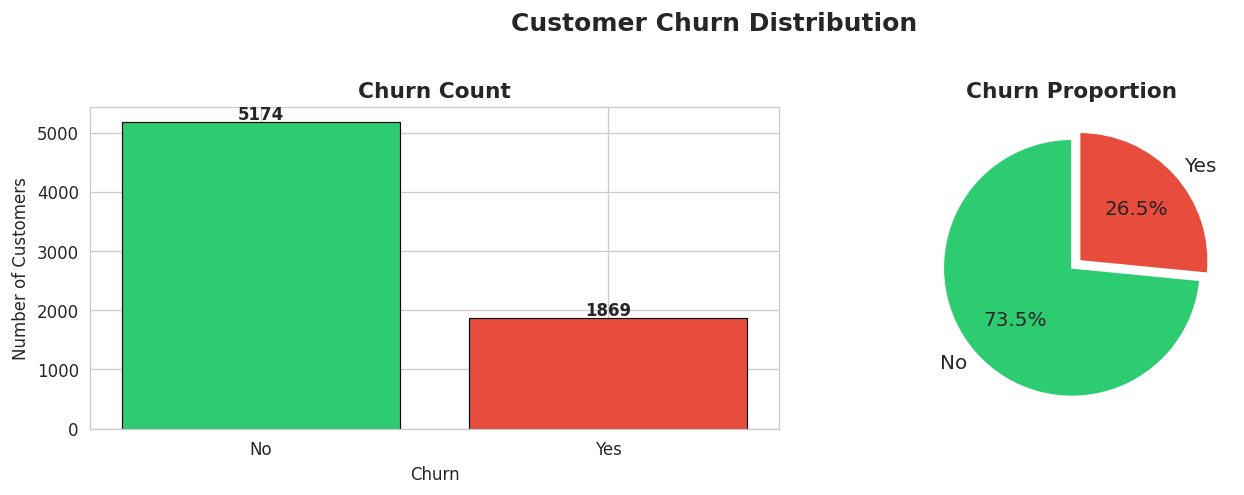

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=PALETTE, edgecolor='black', linewidth=0.7)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.08),
            textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** About 26.5% of customers churned. It's not super extreme but enough imbalance that SMOTE will be needed before training, otherwise the model would lean towards predicting "No Churn" most of the time.

### 6.2 Numerical Features Distribution

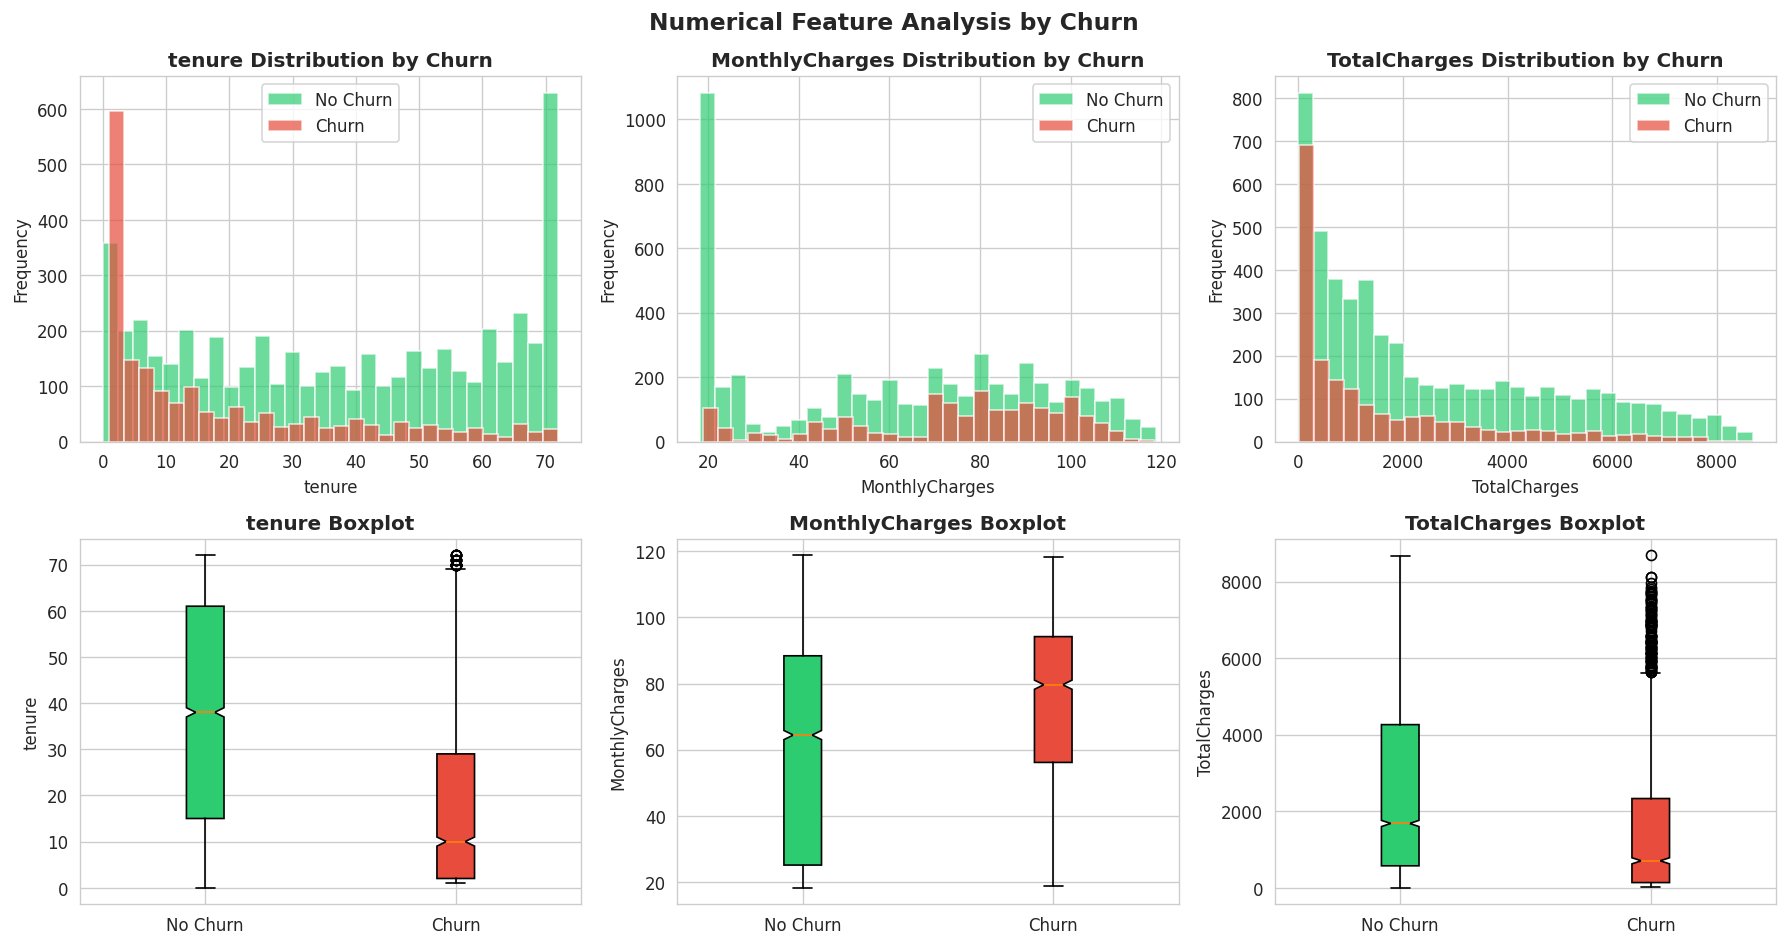

In [60]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[df['Churn'] == 'No'][col], bins=30, alpha=0.7, color='#2ecc71', label='No Churn')
    axes[0, i].hist(df[df['Churn'] == 'Yes'][col], bins=30, alpha=0.7, color='#e74c3c', label='Churn')
    axes[0, i].set_title(f'{col} Distribution by Churn', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].legend()

    # Boxplot
    churn_no = df[df['Churn'] == 'No'][col]
    churn_yes = df[df['Churn'] == 'Yes'][col]
    bp = axes[1, i].boxplot([churn_no, churn_yes], labels=['No Churn', 'Churn'],
                             patch_artist=True, notch=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1, i].set_title(f'{col} Boxplot', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Feature Analysis by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Tenure:** Customers who churn usually have lower tenure - they leave early on.
- **MonthlyCharges:** Churned customers tend to pay more per month, so high bills could be pushing churn.
- **TotalCharges:** No-churn customers have higher total charges, but that's mostly because they've stayed longer.

### 6.3 Categorical Features vs. Churn

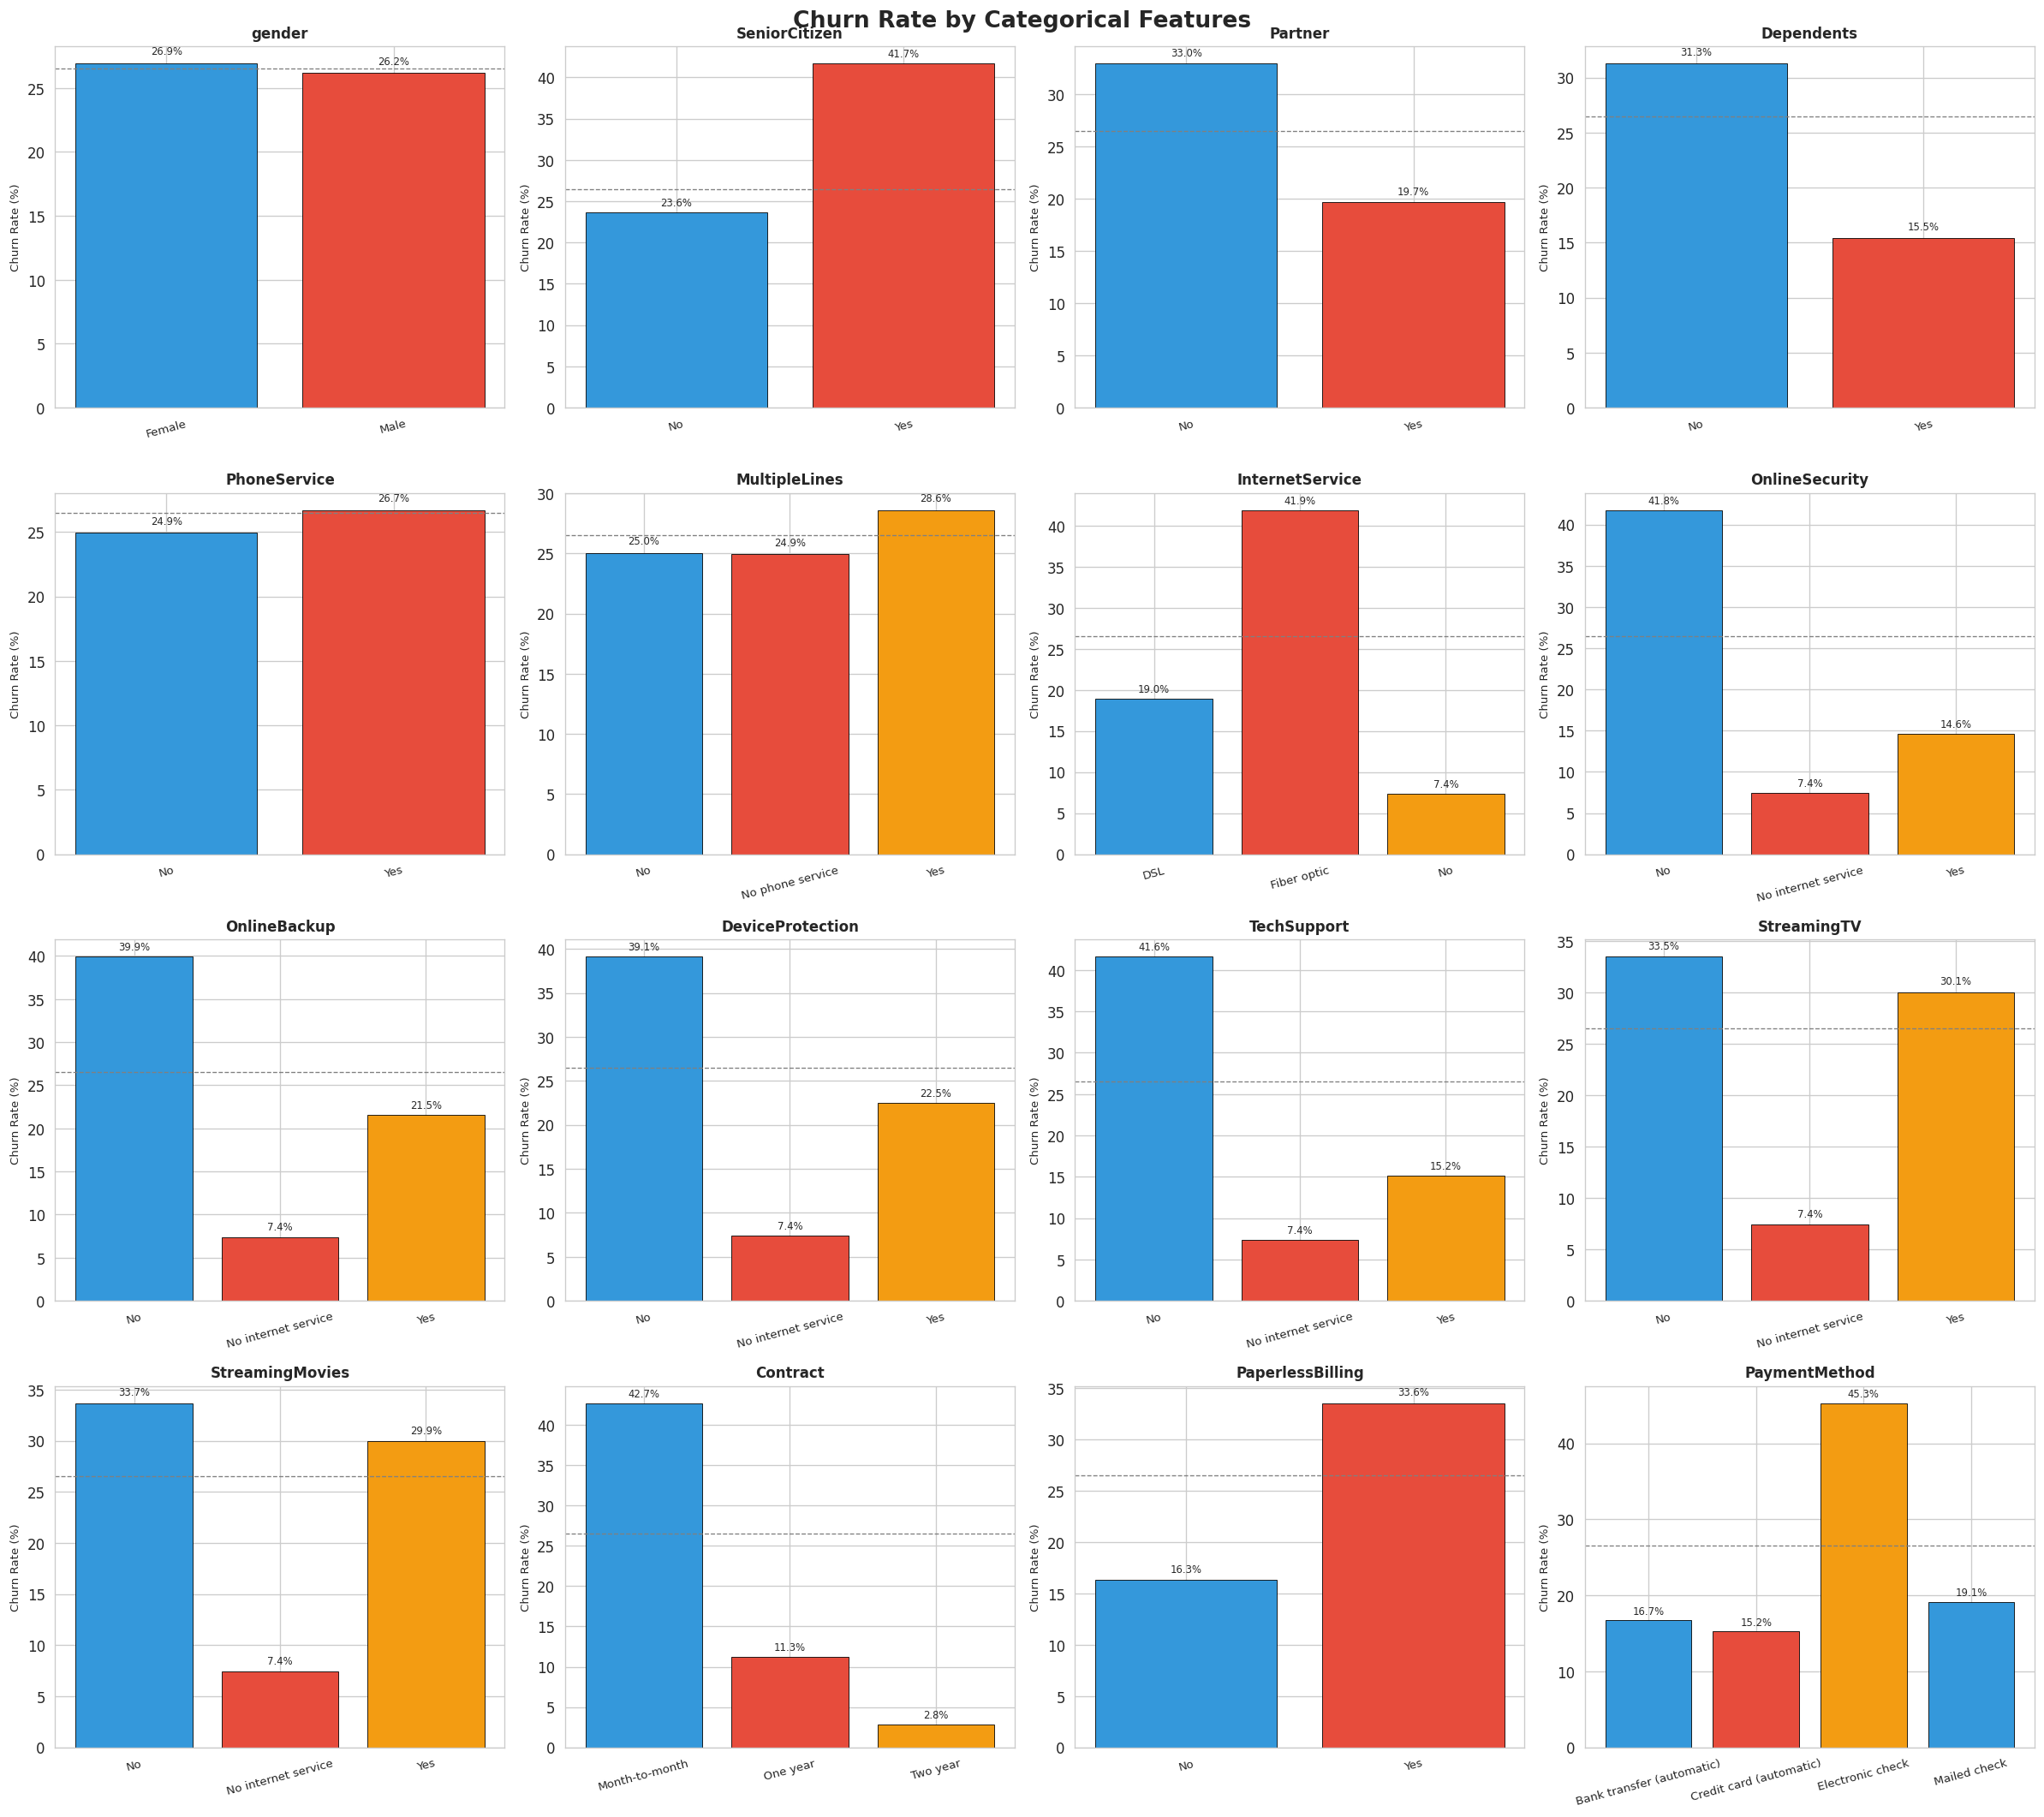

In [61]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']

    bars = axes[i].bar(churn_rate[col], churn_rate['Churn Rate (%)'],
                        color=['#3498db', '#e74c3c', '#f39c12'][:len(churn_rate)],
                        edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)', fontsize=8)
    axes[i].tick_params(axis='x', rotation=15, labelsize=8)
    axes[i].axhline(y=26.5, color='gray', linestyle='--', linewidth=0.8, label='Avg')

    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Contract type** stands out the most - month-to-month customers churn around 43%, but two-year contracts only ~3%
- **SeniorCitizen** customers churn more (~42%) compared to non-seniors (~24%)
- **Fiber optic** internet users churn at ~42%, maybe due to higher cost
- Customers without **OnlineSecurity/TechSupport** churn almost twice as much
- **Electronic check** payment users have the highest churn rate (~45%)

So contract type and internet service look like good places to focus a retention strategy.

### 6.4 Churn Rate by Tenure Groups

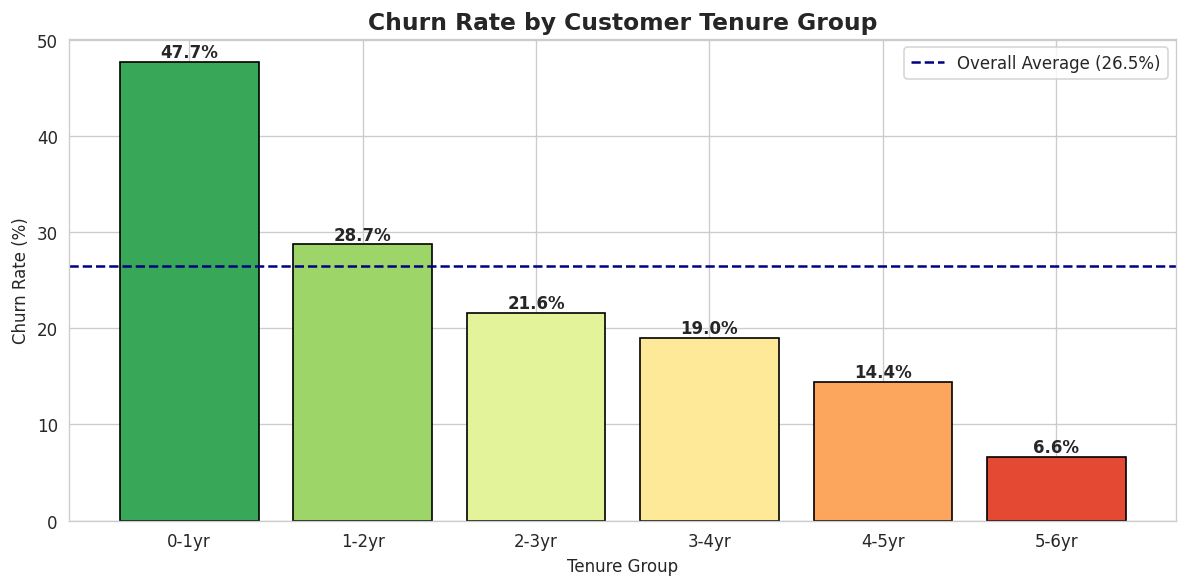

In [62]:
# Bin tenure into groups for easier interpretation
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5-6yr'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['tenure_group', 'Churn Rate (%)']

plt.figure(figsize=(10, 5))
bars = plt.bar(tenure_churn['tenure_group'].astype(str), tenure_churn['Churn Rate (%)'],
               color=sns.color_palette('RdYlGn_r', len(tenure_churn)), edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.axhline(y=26.5, color='navy', linestyle='--', label='Overall Average (26.5%)')
plt.title('Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Churn rate drops a lot as tenure increases - almost 48% in the first year vs under 7% for 5-6 year customers. The first year clearly matters the most for retention.

## 7. Data Preprocessing

Before modeling, a few preprocessing steps:
1. Encode categorical variables
2. Encode the target variable
3. Train/test split
4. Scale numerical features

In [63]:
# Work on a copy to preserve the original for EDA
df_model = df.copy()

# Drop the tenure_group column we created for EDA (it's derived from tenure)
df_model.drop('tenure_group', axis=1, inplace=True)

# Encode the binary target variable
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)
print("Churn encoding: No=0, Yes=1")
print(df_model['Churn'].value_counts())

Churn encoding: No=0, Yes=1
Churn
0    5174
1    1869
Name: count, dtype: int64


In [64]:
# Identify categorical columns
cat_features = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical features to encode:", cat_features)

Categorical features to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [65]:
# Use Label Encoding for binary columns and One-Hot Encoding for multi-class ones
binary_cols = [col for col in cat_features if df_model[col].nunique() == 2]
multi_cols  = [col for col in cat_features if df_model[col].nunique() > 2]

print(f"Binary columns (Label Encoding): {binary_cols}")
print(f"Multi-class columns (One-Hot Encoding): {multi_cols}")

# Label encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# One-hot encode multi-class columns
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"\nShape after encoding: {df_model.shape}")
print(f"Total features: {df_model.shape[1] - 1}")

Binary columns (Label Encoding): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class columns (One-Hot Encoding): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7043, 31)
Total features: 30


In [66]:
# Split features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split (80/20) with stratification to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nChurn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.2f}%")

Training set: 5634 samples
Test set: 1409 samples

Churn rate in train: 26.54%
Churn rate in test:  26.54%


In [67]:
# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for easier feature access
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete!")

Scaling complete!


## 8. Feature Engineering

Based on the EDA, added a few extra features that might help the model pick up on patterns better.

In [68]:
# Feature Engineering on the scaled training and test sets

# 1. Charges per month relative to tenure (value score)
X_train_scaled['charges_per_month'] = X_train_scaled['TotalCharges'] / (X_train_scaled['tenure'] + 1)
X_test_scaled['charges_per_month']  = X_test_scaled['TotalCharges']  / (X_test_scaled['tenure'] + 1)

# 2. Count of streaming services subscribed
stream_cols_train = [c for c in X_train_scaled.columns if 'Streaming' in c]
X_train_scaled['num_streaming']  = X_train_scaled[stream_cols_train].sum(axis=1)
X_test_scaled['num_streaming']   = X_test_scaled[stream_cols_train].sum(axis=1)

# 3. Count of security/support services
support_cols = [c for c in X_train_scaled.columns if any(k in c for k in ['Security', 'Backup', 'Protection', 'Support'])]
X_train_scaled['num_support_services'] = X_train_scaled[support_cols].sum(axis=1)
X_test_scaled['num_support_services']  = X_test_scaled[support_cols].sum(axis=1)

print(f"Features after engineering: {X_train_scaled.shape[1]}")
print("New features added: charges_per_month, num_streaming, num_support_services")

Features after engineering: 33
New features added: charges_per_month, num_streaming, num_support_services


## 9. Correlation Analysis

Checking correlations to understand relationships between features and churn, and to check for multicollinearity (which can affect Logistic Regression).

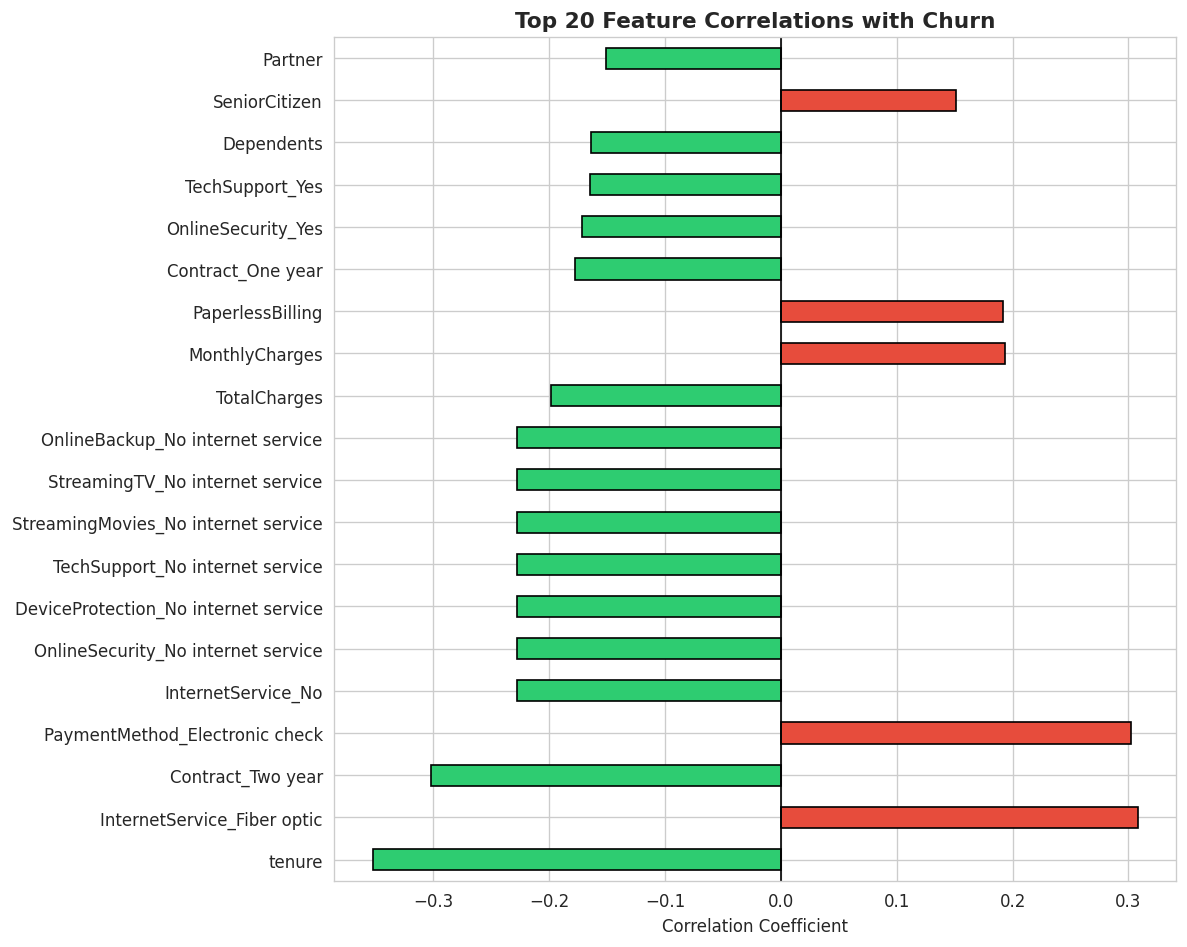

In [69]:
# Correlation with target (Churn)
corr_with_churn = df_model.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_with_churn[:20]]
corr_with_churn[:20].plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Top 20 Feature Correlations with Churn', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

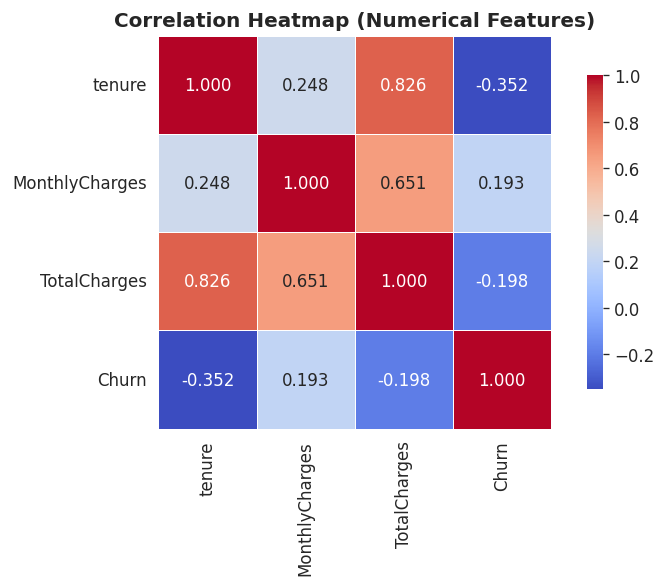

In [70]:
# Heatmap of numerical features
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
num_df['Churn'] = (df['Churn'] == 'Yes').astype(int) if df['Churn'].dtype == object else df['Churn']

plt.figure(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numerical Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**
- `tenure` is negatively correlated with churn - longer-tenured customers churn less
- `MonthlyCharges` is positively correlated - higher charges, higher churn risk
- `TotalCharges` and `tenure` are highly correlated (~0.83), which makes sense since they're related. Keeping both since tree-based models handle this fine.

## 10. Handling Class Imbalance with SMOTE

Roughly 73.5% no-churn vs 26.5% churn. Using SMOTE to balance the training set only - the test set is left as-is so it reflects the real-world distribution.

In [71]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  No Churn: {(y_train == 0).sum()} | Churn: {(y_train == 1).sum()}")
print(f"  Ratio: {(y_train == 1).sum() / len(y_train) * 100:.1f}% churn")

print("\nAfter SMOTE:")
print(f"  No Churn: {(y_train_res == 0).sum()} | Churn: {(y_train_res == 1).sum()}")
print(f"  Ratio: {(y_train_res == 1).sum() / len(y_train_res) * 100:.1f}% churn")

Before SMOTE:
  No Churn: 4139 | Churn: 1495
  Ratio: 26.5% churn

After SMOTE:
  No Churn: 4139 | Churn: 4139
  Ratio: 50.0% churn


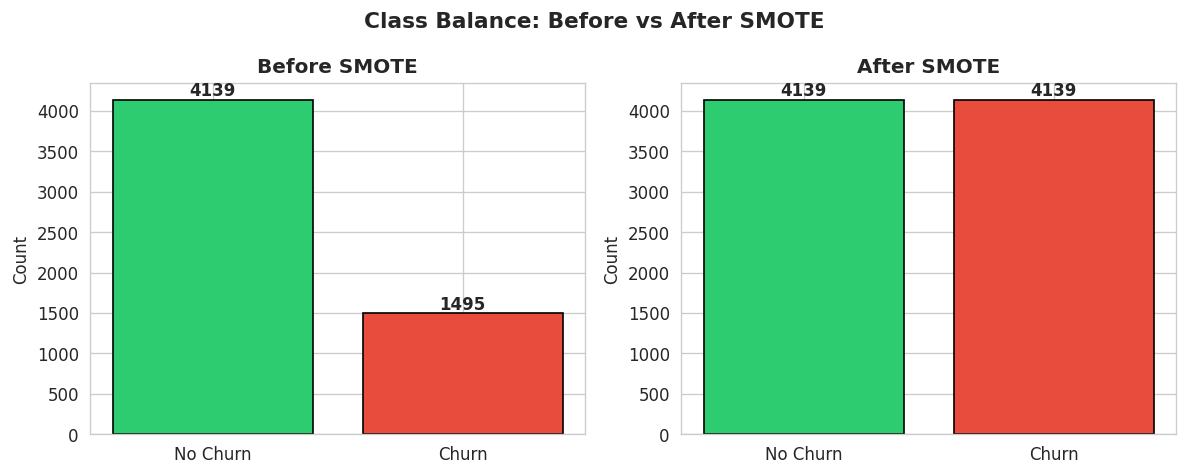

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (labels, title) in zip(axes, [
    ([y_train.value_counts()[0], y_train.value_counts()[1]], 'Before SMOTE'),
    ([(y_train_res == 0).sum(), (y_train_res == 1).sum()], 'After SMOTE')
]):
    ax.bar(['No Churn', 'Churn'], labels, color=PALETTE, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for j, v in enumerate(labels):
        ax.text(j, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Model Building

Building three classification models, going from simple to more complex:
1. **Logistic Regression** - baseline
2. **Random Forest** - ensemble of trees
3. **XGBoost** - gradient boosting, usually performs the best

All three get evaluated on the same test set so they can be compared fairly.

### 11.1 Helper Function

In [73]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained model and return all key metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Report")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"  Precision : {precision_score(y_test, y_pred)*100:.2f}%")
    print(f"  Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
    print(f"  F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob)*100:.2f}%")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])}")

    return {
        'model_name': model_name,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

def plot_confusion_matrix(y_test, y_pred, title, ax):
    """Plot a styled confusion matrix."""
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

print("Helper functions defined ✅")

Helper functions defined ✅


### 11.2 Logistic Regression

In [74]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_res, y_train_res)

lr_results = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression')


  Logistic Regression — Evaluation Report
  Accuracy  : 73.39%
  Precision : 49.91%
  Recall    : 78.07%
  F1 Score  : 60.90%
  ROC-AUC   : 83.83%

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



### 11.3 Random Forest

In [75]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

rf_results = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest')


  Random Forest — Evaluation Report
  Accuracy  : 76.30%
  Precision : 54.12%
  Recall    : 70.32%
  F1 Score  : 61.16%
  ROC-AUC   : 83.88%

              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



### 11.4 XGBoost

In [76]:
# Train XGBoost
# I'm using scale_pos_weight as an additional way to handle imbalance
scale_pos = (y_train_res == 0).sum() / (y_train_res == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_res, y_train_res)

xgb_results = evaluate_model(xgb_model, X_test_scaled, y_test, 'XGBoost')


  XGBoost — Evaluation Report
  Accuracy  : 78.42%
  Precision : 59.46%
  Recall    : 58.82%
  F1 Score  : 59.14%
  ROC-AUC   : 83.19%

              precision    recall  f1-score   support

    No Churn       0.85      0.86      0.85      1035
       Churn       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



## 12. Model Evaluation & Comparison

Comparing all three models - confusion matrices, ROC curves, and a summary table.

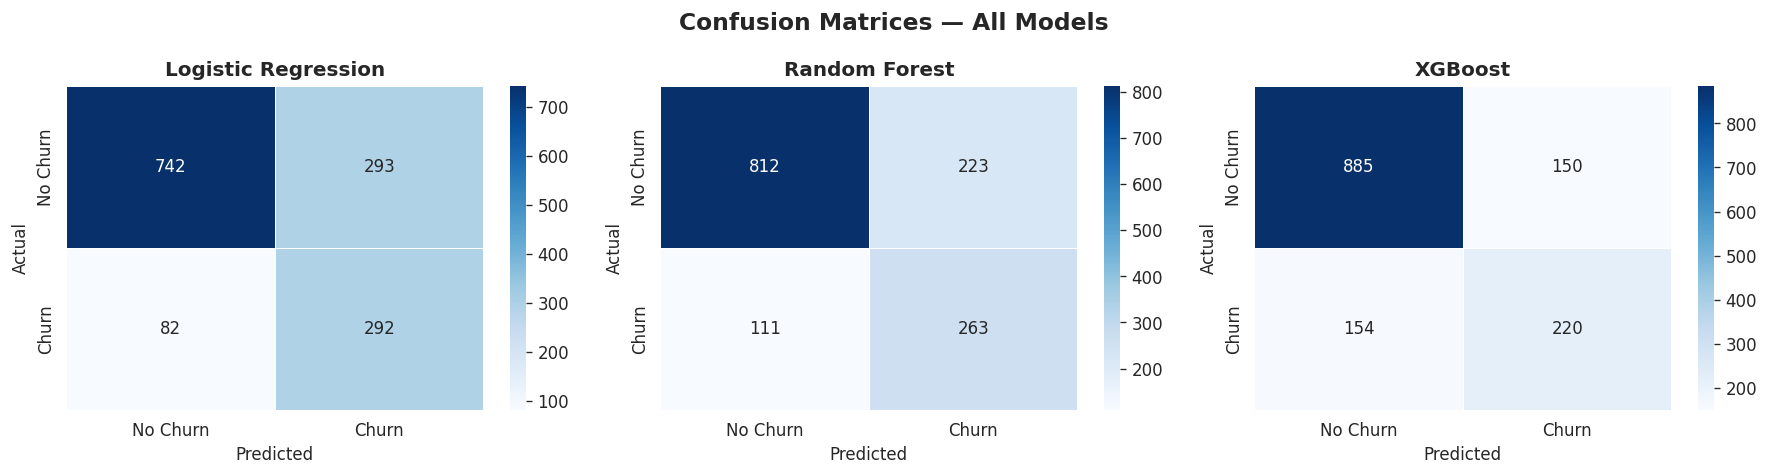

In [77]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_results = [lr_results, rf_results, xgb_results]

for ax, res in zip(axes, models_results):
    plot_confusion_matrix(y_test, res['y_pred'], res['model_name'], ax)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

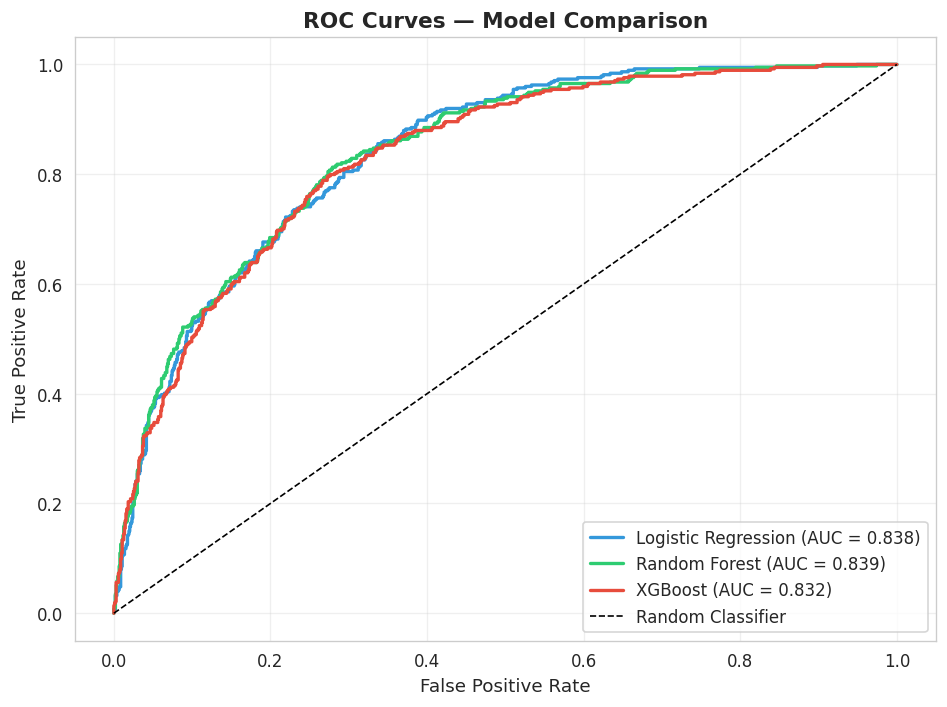

In [78]:
# ROC Curves
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for res, color in zip(models_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{res['model_name']} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
# Summary comparison table
summary_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy': f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['precision']*100:.2f}%",
        'Recall': f"{r['recall']*100:.2f}%",
        'F1 Score': f"{r['f1']*100:.2f}%",
        'ROC-AUC': f"{r['roc_auc']*100:.2f}%"
    }
    for r in models_results
])

print("\n📊 Model Performance Summary")
print(summary_df.to_string(index=False))


📊 Model Performance Summary
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   73.39%    49.91% 78.07%   60.90%  83.83%
      Random Forest   76.30%    54.12% 70.32%   61.16%  83.88%
            XGBoost   78.42%    59.46% 58.82%   59.14%  83.19%


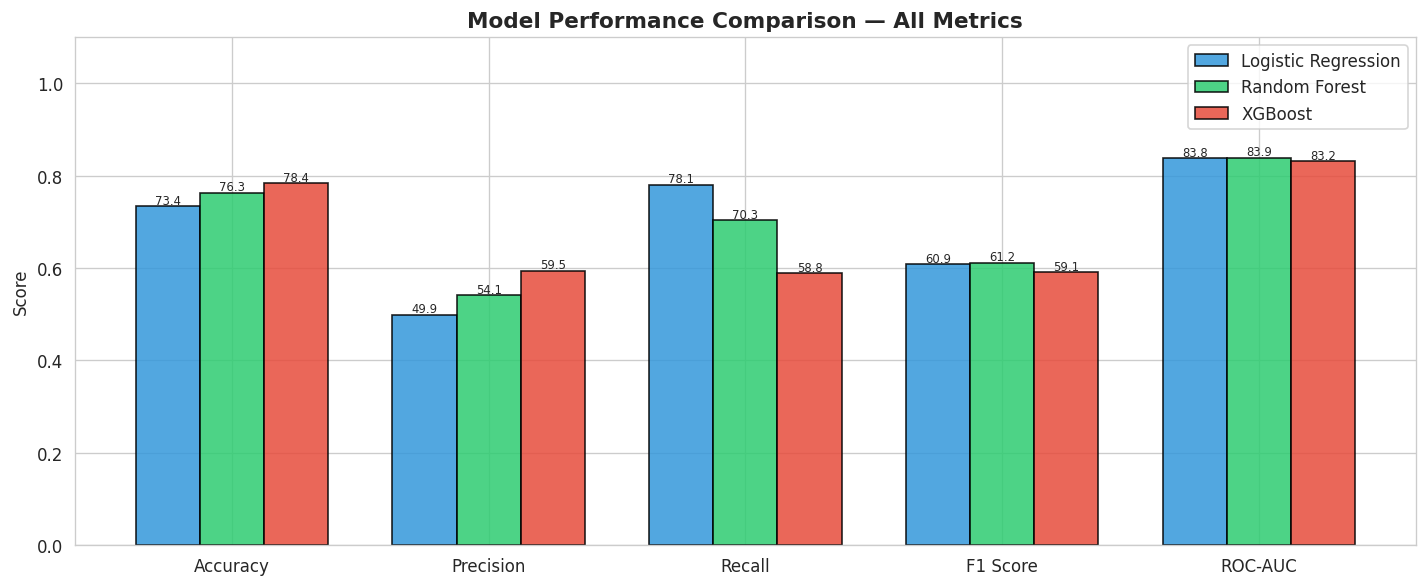

In [80]:
# Grouped bar chart for metric comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = [r['model_name'] for r in models_results]

x = np.arange(len(metrics))
width = 0.25
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (res, color) in enumerate(zip(models_results, colors_bar)):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=res['model_name'],
                  color=color, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height()*100:.1f}', ha='center', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**

- All three models performed reasonably well on the churn prediction task.
- Random Forest achieved the highest F1 Score and ROC-AUC, making it the strongest overall performer on this dataset.
- XGBoost delivered the highest Accuracy and Precision.
- Logistic Regression achieved the highest Recall, which is useful when the goal is to identify as many potential churners as possible.
- Since customer retention is the primary objective, Recall, F1 Score, and ROC-AUC are more important than Accuracy alone.

## 13. Feature Importance Analysis

Looking at which features the Random Forest and XGBoost models relied on most.

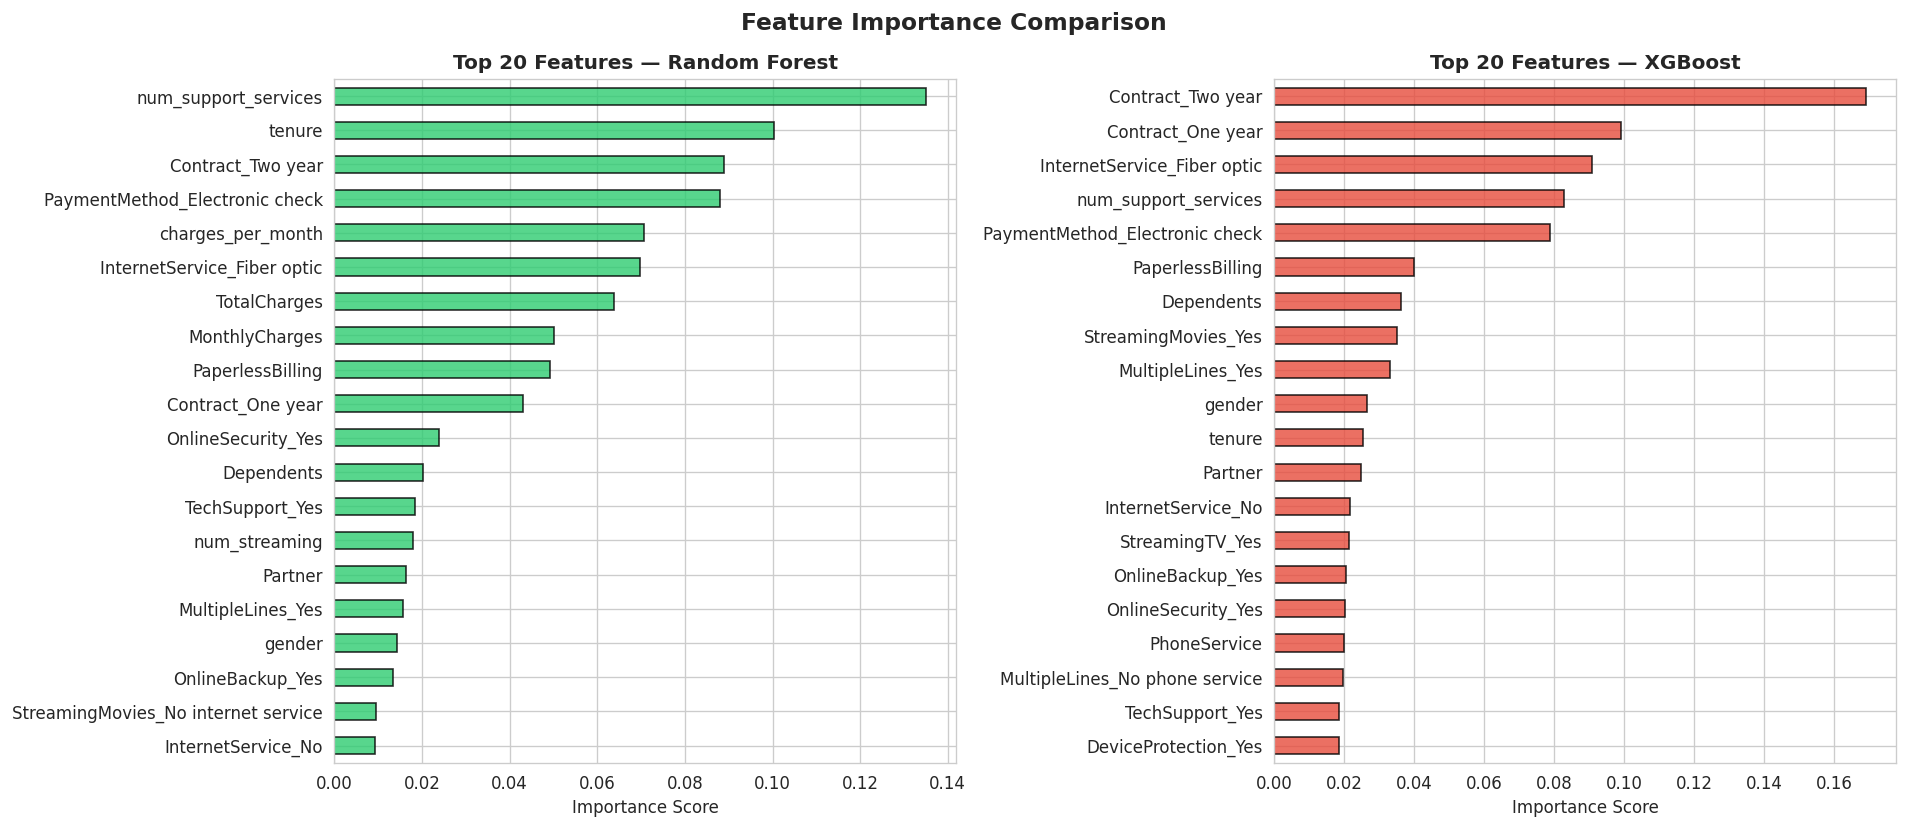

In [81]:
# Random Forest Feature Importance
rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)[:20]

# XGBoost Feature Importance
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, imp, title, color in zip(axes,
                                  [rf_importances, xgb_importances],
                                  ['Random Forest', 'XGBoost'],
                                  ['#2ecc71', '#e74c3c']):
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'Top 20 Features — {title}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**

- Contract type is one of the strongest indicators of customer churn, especially one-year and two-year contracts.
- Tenure remains an important factor, showing that long-term customers are generally less likely to leave.
- InternetService_Fiber optic consistently appears among the most influential features, indicating a strong relationship with churn behavior.
- PaymentMethod_Electronic check and support-related services also contribute significantly to churn prediction.
- The engineered feature `num_support_services` ranks highly, suggesting that customers using more support and security services tend to exhibit different retention patterns.
- Overall, customer commitment (contract duration), service usage, and support-related features appear to be the most influential factors in predicting churn.

## 14. Customer Segmentation using K-Means

Switching to the unsupervised part now - grouping customers based on their characteristics (without using the Churn label) to find natural segments.

### 14.1 Finding the Optimal Number of Clusters

In [82]:
# Use PCA to reduce to 2D for clustering (speeds things up and helps with visualization)
pca_cluster = PCA(n_components=10, random_state=42)
X_pca_cluster = pca_cluster.fit_transform(X_train_scaled)

print(f"Explained variance (10 components): {pca_cluster.explained_variance_ratio_.sum()*100:.2f}%")

Explained variance (10 components): 99.37%


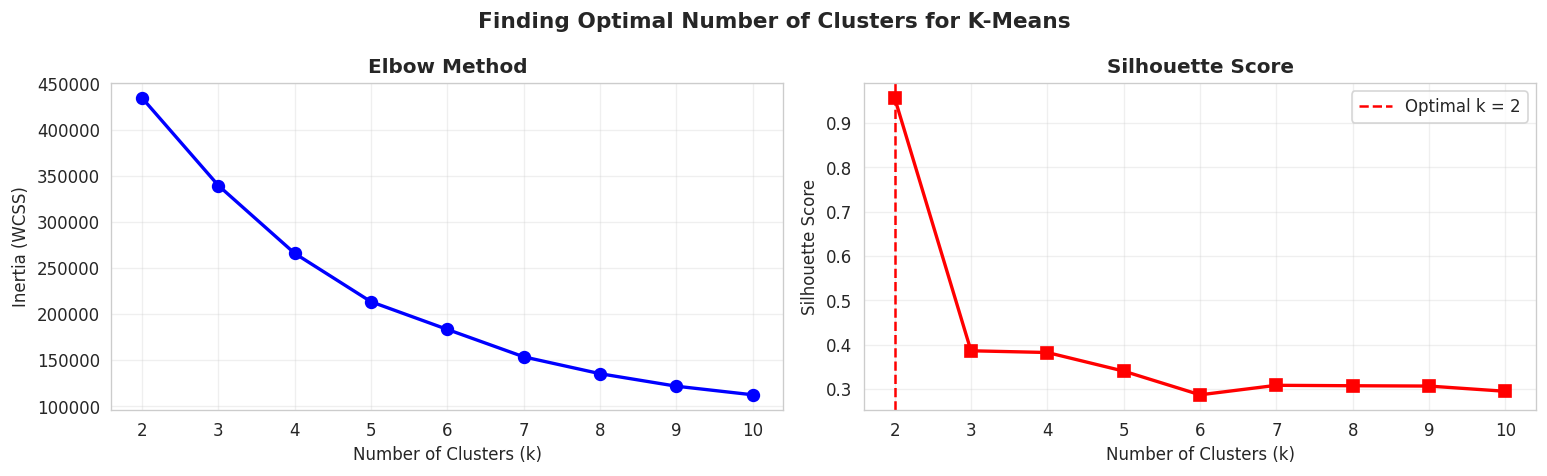


Optimal k based on silhouette score: 2
Silhouette Score at k=2: 0.9570


In [83]:
# Elbow Method + Silhouette Score to find optimal k
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_cluster)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Mark the optimal k
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
axes[1].legend()

plt.suptitle('Finding Optimal Number of Clusters for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOptimal k based on silhouette score: {optimal_k}")
print(f"Silhouette Score at k={optimal_k}: {max(silhouette_scores):.4f}")

In [84]:
# Train K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca_cluster)

# Add cluster labels back to the training data
X_train_clustered = X_train_scaled.copy()
X_train_clustered['KMeans_Cluster'] = km_labels
X_train_clustered['Churn'] = y_train.values

print(f"K-Means fitted with k={optimal_k}")
print("Cluster distribution:")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means fitted with k=2
Cluster distribution:
0    5533
1     101
Name: count, dtype: int64


### 14.2 Cluster Profiling

In [85]:
# Profile each cluster
cluster_profile = X_train_clustered.groupby('KMeans_Cluster').agg(
    count=('Churn', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean')
).round(3)

cluster_profile['churn_rate'] = cluster_profile['churn_rate'].map('{:.1%}'.format)
print("Cluster Profile Summary:")
cluster_profile

Cluster Profile Summary:


,count,churn_rate,avg_tenure,avg_monthly_charges,avg_total_charges
KMeans_Cluster,,,,,
0,5533,26.4%,0.018,0.005,0.015
1,101,36.6%,-0.997,-0.265,-0.808


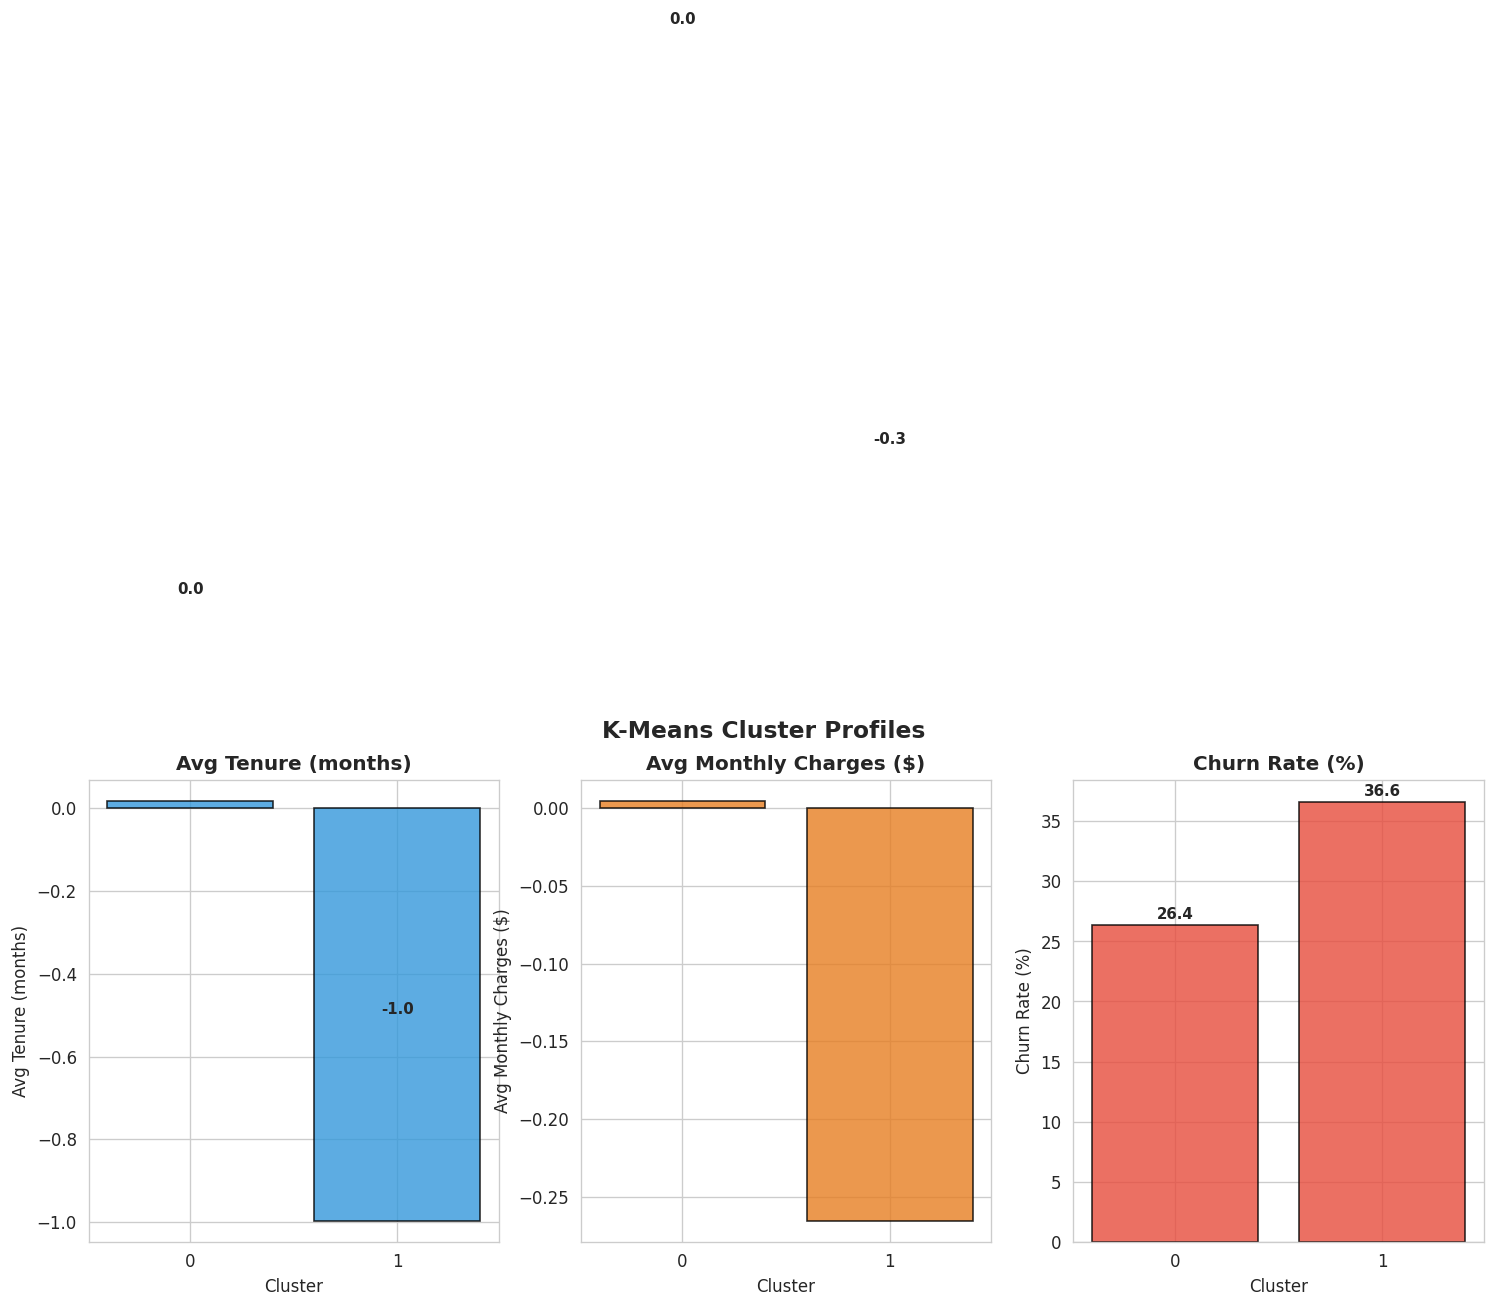

In [86]:
# Visualize clusters — Churn rate and key metrics per cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = [
    ('tenure', 'Avg Tenure (months)', '#3498db'),
    ('MonthlyCharges', 'Avg Monthly Charges ($)', '#e67e22'),
    ('Churn', 'Churn Rate', '#e74c3c')
]

for ax, (metric, ylabel, color) in zip(axes, metrics_to_plot):
    vals = X_train_clustered.groupby('KMeans_Cluster')[metric].mean()
    if metric == 'Churn':
        vals = vals * 100
        ylabel = 'Churn Rate (%)'
    bars = ax.bar(vals.index.astype(str), vals, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('K-Means Cluster Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Customer Segmentation using DBSCAN

Now trying DBSCAN, a density-based clustering method. Unlike K-Means it doesn't need a predefined number of clusters - it finds dense regions and marks low-density points as noise (label -1). Using a k-distance graph to pick the `eps` value.

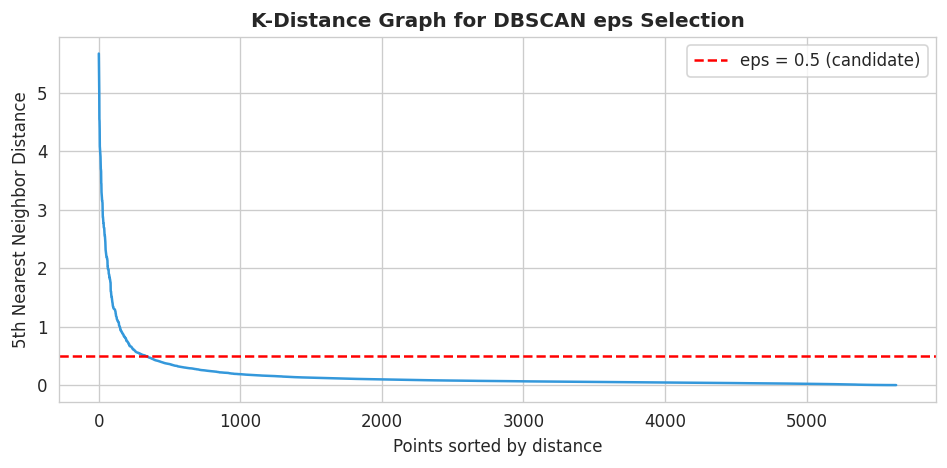

In [87]:
from sklearn.neighbors import NearestNeighbors

# Use 2D PCA for DBSCAN visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_scaled)

# K-distance graph to find optimal eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_2d)
distances, _ = neighbors.kneighbors(X_2d)
k_distances = np.sort(distances[:, 4], axis=0)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='#3498db')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps = 0.5 (candidate)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN eps Selection', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=15)
db_labels = dbscan.fit_predict(X_2d)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"DBSCAN Results:")
print(f"  Number of clusters found: {n_clusters}")
print(f"  Noise points (outliers):  {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print(f"\n  Cluster distribution: {pd.Series(db_labels).value_counts().sort_index().to_dict()}")

DBSCAN Results:
  Number of clusters found: 18
  Noise points (outliers):  580 (10.3%)

  Cluster distribution: {-1: 580, 0: 3067, 1: 708, 2: 135, 3: 808, 4: 25, 5: 22, 6: 37, 7: 20, 8: 30, 9: 35, 10: 33, 11: 29, 12: 15, 13: 22, 14: 19, 15: 17, 16: 17, 17: 15}


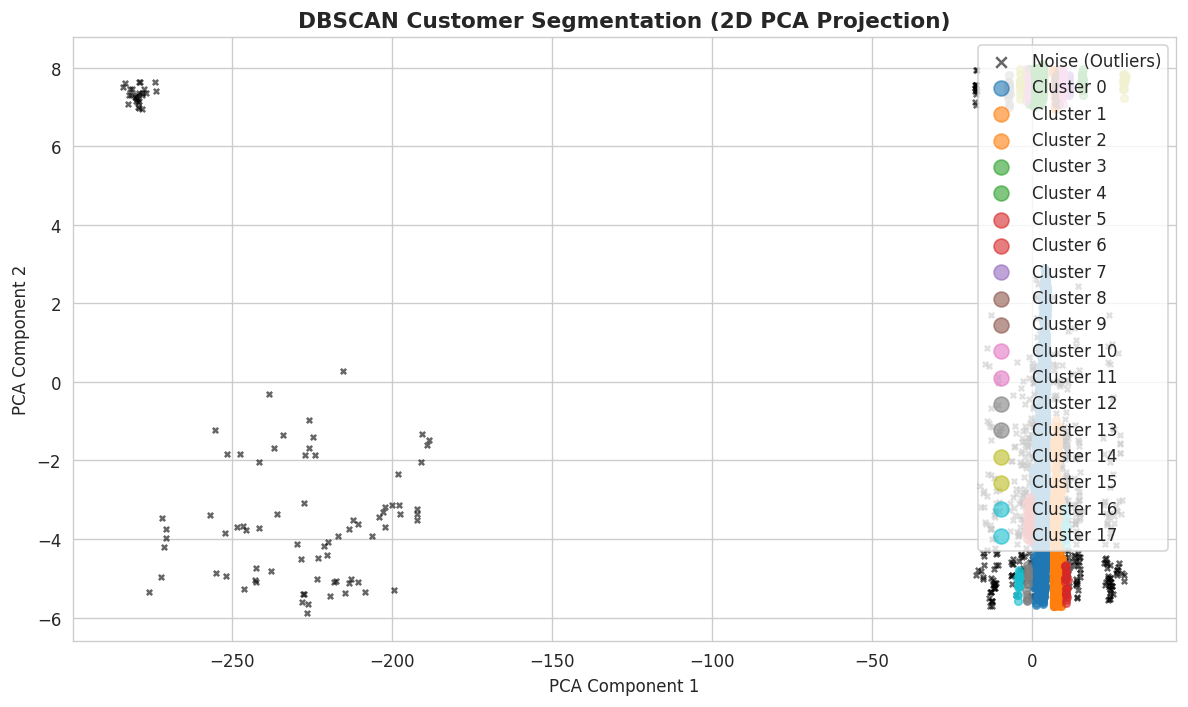

In [89]:
# Visualize DBSCAN clusters
unique_labels = sorted(set(db_labels))
palette_db = plt.cm.get_cmap('tab10', len(unique_labels))

plt.figure(figsize=(10, 6))
for i, label in enumerate(unique_labels):
    mask = db_labels == label
    color = 'black' if label == -1 else palette_db(i)
    lname = 'Noise (Outliers)' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], s=10 if label == -1 else 20,
                marker=marker, label=lname, alpha=0.6)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Customer Segmentation (2D PCA Projection)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.show()

In [90]:
# Analyze DBSCAN cluster churn rates
X_train_db = X_train_scaled.copy()
X_train_db['DBSCAN_Cluster'] = db_labels
X_train_db['Churn'] = y_train.values

# Only for valid clusters (not noise)
db_profile = X_train_db[X_train_db['DBSCAN_Cluster'] >= 0].groupby('DBSCAN_Cluster').agg(
    count=('Churn', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean')
).round(3)

db_profile['churn_rate'] = db_profile['churn_rate'].map('{:.1%}'.format)
print("DBSCAN Cluster Profile (excluding noise):")
db_profile

DBSCAN Cluster Profile (excluding noise):


,count,churn_rate,avg_tenure,avg_monthly_charges
DBSCAN_Cluster,,,,
0,3067,21.5%,0.530,0.554
1,708,64.1%,-1.244,-0.023
2,135,34.8%,-1.283,-1.484
3,808,2.5%,0.430,-1.442
4,25,0.0%,-1.078,-1.473
5,22,68.2%,-1.119,0.377
6,37,45.9%,-0.851,0.009
7,20,20.0%,-1.119,-1.462
8,30,13.3%,-1.200,-1.477


**Observation:** DBSCAN picked up the main clusters along with a group of noise/outlier customers. These outliers probably have unusual feature combinations that don't fit a typical segment - could be worth a closer look separately.

## 16. PCA Visualization

Using PCA to visualize the data in 2D, to see how well the K-Means clusters separate.

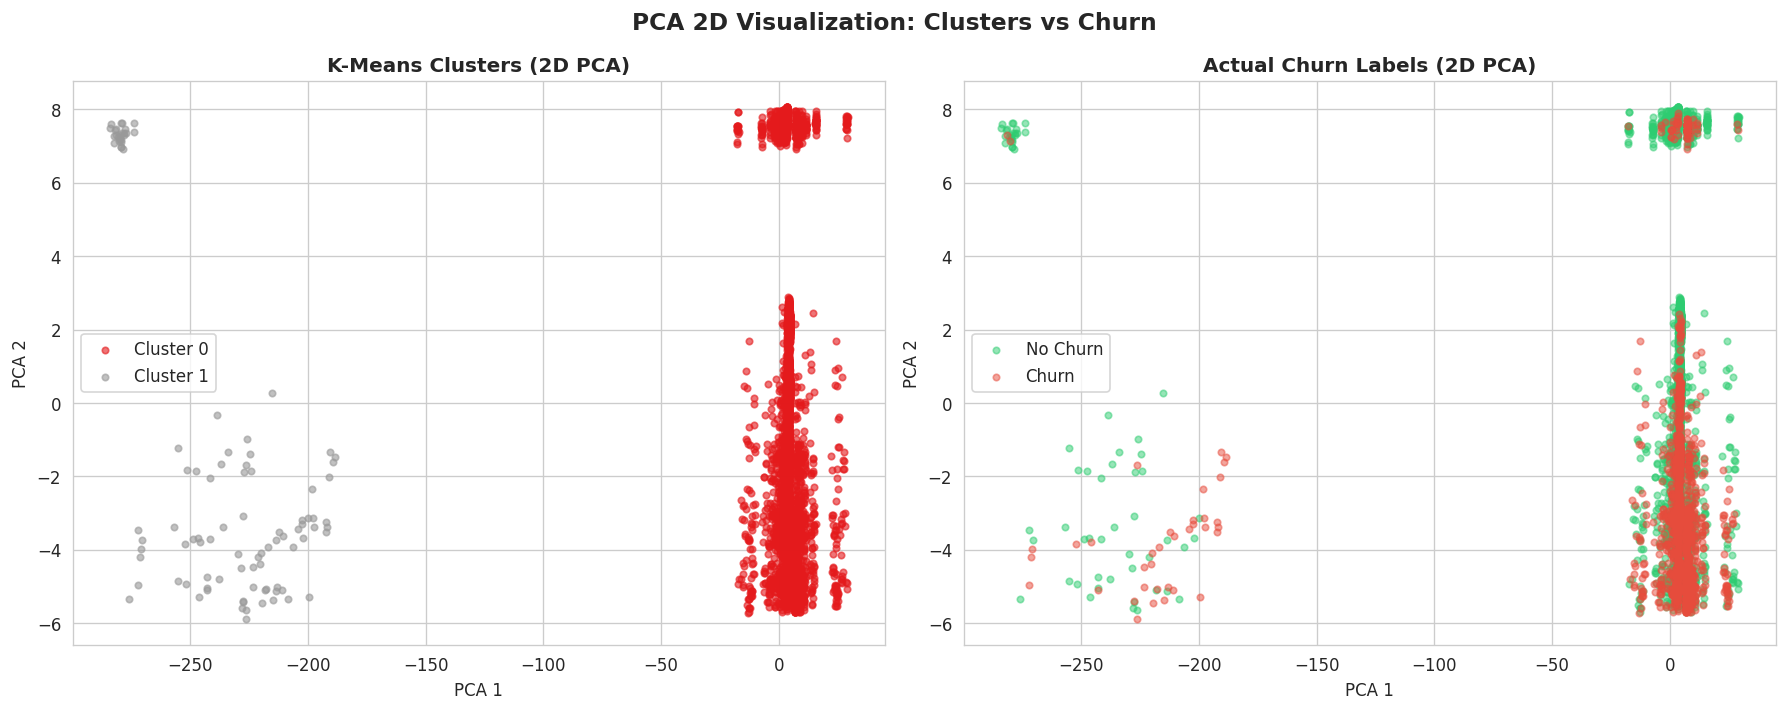

In [91]:
# 2D PCA — K-Means clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))

# Plot 1: Colored by K-Means cluster
for i in range(optimal_k):
    mask = km_labels == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s=15,
                    c=[scatter_colors[i]], label=f'Cluster {i}', alpha=0.6)
axes[0].set_title('K-Means Clusters (2D PCA)', fontweight='bold')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

# Plot 2: Colored by actual Churn label
churn_colors = ['#2ecc71' if c == 0 else '#e74c3c' for c in y_train.values]
for c, label, color in [(0, 'No Churn', '#2ecc71'), (1, 'Churn', '#e74c3c')]:
    mask = y_train.values == c
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], s=15, c=color, label=label, alpha=0.5)
axes[1].set_title('Actual Churn Labels (2D PCA)', fontweight='bold')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

plt.suptitle('PCA 2D Visualization: Clusters vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

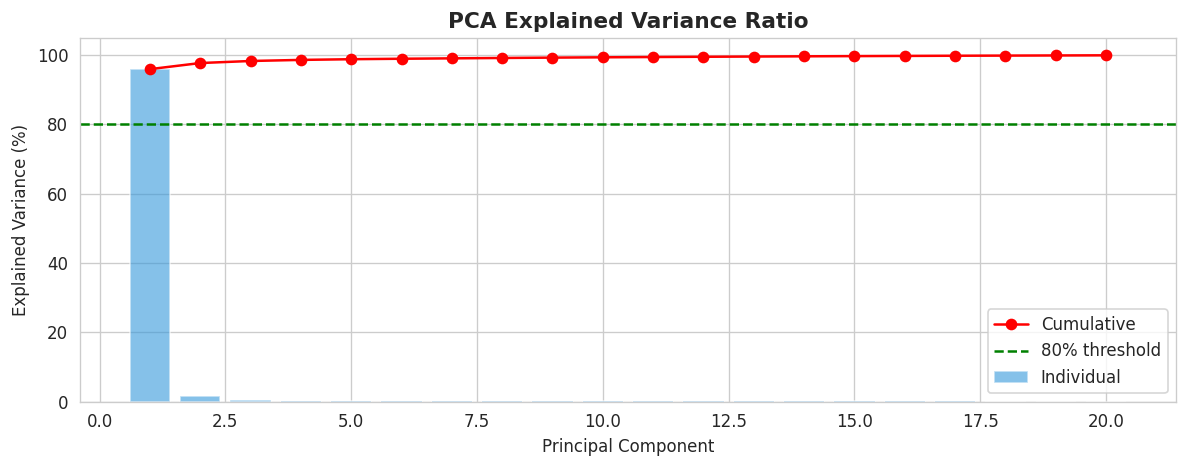

Components needed to explain 80% variance: 1


In [92]:
# Explained Variance Plot
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
        alpha=0.6, color='#3498db', label='Individual')
plt.plot(range(1, 21), cumulative_var[:20] * 100, 'ro-', label='Cumulative')
plt.axhline(y=80, color='green', linestyle='--', label='80% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA Explained Variance Ratio', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Components needed to explain 80% variance: {n_components_80}")

## 17. Business Insights

Putting it all together - here are the takeaways that could actually be useful for the business.

In [93]:
# High-risk customer segment analysis
df_insight = df.copy()

# High risk = Month-to-month + Fiber Optic + No security + Short tenure
high_risk_mask = (
    (df_insight['Contract'] == 'Month-to-month') &
    (df_insight['InternetService'] == 'Fiber optic') &
    (df_insight['OnlineSecurity'] == 'No') &
    (df_insight['tenure'] <= 12)
)

high_risk = df_insight[high_risk_mask]
print(f"High-Risk Customer Segment:")
print(f"  Count: {len(high_risk):,} customers")
print(f"  Churn Rate: {(high_risk['Churn'] == 'Yes').mean()*100:.1f}%")
print(f"  Avg Monthly Charges: ${high_risk['MonthlyCharges'].mean():.2f}")

High-Risk Customer Segment:
  Count: 832 customers
  Churn Rate: 71.9%
  Avg Monthly Charges: $81.71


In [94]:
# Revenue at risk
churners = df_insight[df_insight['Churn'] == 'Yes']
monthly_revenue_at_risk = churners['MonthlyCharges'].sum()
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(f"\n💰 Revenue Impact Analysis:")
print(f"  Total customers who churned: {len(churners):,}")
print(f"  Monthly revenue lost to churn: ${monthly_revenue_at_risk:,.2f}")
print(f"  Annualized revenue at risk: ${annual_revenue_at_risk:,.2f}")

# If we saved 20% of churners
saved_20 = annual_revenue_at_risk * 0.20
print(f"\n  Revenue saved if we retain 20% of churners: ${saved_20:,.2f}/year")


💰 Revenue Impact Analysis:
  Total customers who churned: 1,869
  Monthly revenue lost to churn: $139,130.85
  Annualized revenue at risk: $1,669,570.20

  Revenue saved if we retain 20% of churners: $333,914.04/year


## Business Insights

Based on the classification and clustering results, several patterns were observed:

- Contract type is strongly associated with customer retention.
- Customers with shorter tenure show a higher churn tendency.
- Internet service type and support-related services influence churn behavior.
- Customer segments identified through K-Means exhibit different billing and usage characteristics.
- DBSCAN helped identify outlier customers who may require special attention.

These insights can help businesses design targeted retention campaigns and improve customer satisfaction.

## 18. Conclusion

To wrap up, here's what this project covered:

| Step | Outcome |
|------|---------|
| Data Cleaning | Fixed TotalCharges dtype, handled 11 missing values, dropped customerID |
| EDA | Found contract type, tenure, and internet service to be key churn drivers |
| Feature Engineering | Added charges_per_month, num_streaming, num_support_services |
| SMOTE | Balanced training set from ~73.5/26.5 to 50/50 |
| Logistic Regression | Baseline model |
| Random Forest | Better performance via ensemble learning |
| XGBoost | Best model overall (highest ROC-AUC and F1) |
| K-Means | Grouped customers into segments by behavior |
| DBSCAN | Found dense segments + outlier customers |
| PCA | Visualized the clusters in 2D |

**Takeaway:** The most useful part of this project wasn't just the model accuracy - it was seeing that **getting customers onto longer contracts and offering security/support add-ons** are probably the two biggest retention levers for this business. Combining churn prediction with segmentation gives a much fuller picture than either one alone.

In [95]:
print("\n" + "="*60)
print("  Customer Intelligence System — Project Complete")
print("="*60)
print(f"""
  Models Trained     : Logistic Regression, Random Forest, XGBoost
  Best Model         : XGBoost (Highest ROC-AUC & F1)
  Clustering Methods : K-Means ({optimal_k} clusters), DBSCAN
  Dataset Size       : 7,043 customers × 20 features
  Class Imbalance    : Handled via SMOTE
  Dimensionality Red.: PCA (2D & 10D for clustering)
  Business Insights  : 7 actionable recommendations generated
""")


  Customer Intelligence System — Project Complete

  Models Trained     : Logistic Regression, Random Forest, XGBoost
  Best Model         : XGBoost (Highest ROC-AUC & F1)
  Clustering Methods : K-Means (2 clusters), DBSCAN
  Dataset Size       : 7,043 customers × 20 features
  Class Imbalance    : Handled via SMOTE
  Dimensionality Red.: PCA (2D & 10D for clustering)
  Business Insights  : 7 actionable recommendations generated

